# 1. Base de datos

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

Este capítulo cubre la **Sección 1 de las instrucciones del proyecto**: problema de investigación,
justificación y fuente del dataset, diccionario de variables, estructura de
los datos, tamaño de muestra y calidad de datos (duplicados, valores
imposibles, categorías mal escritas), más las consideraciones éticas.

```{important}
Todo lo que se hace en este capítulo son **reglas fila a fila** que no
aprenden nada de otras filas (por ejemplo "un año de construcción de 1512 es
imposible"). Ninguna de ellas usa estadísticas del conjunto de datos, por eso
pueden aplicarse **antes** de reservar el conjunto de prueba (capítulo 2) sin
generar fuga de información. Todo lo que sí aprende de los datos (medianas
para imputar, umbrales de outliers, escalado) se calcula después, solo con
entrenamiento.
```

In [1]:
# Celda de configuración: importa librerías y los módulos propios de src/.
# Toda la lógica reutilizable (rutas, semillas, reglas de limpieza) vive en src/
# para que cada capítulo use exactamente las mismas definiciones (reproducibilidad).
import sys
import warnings
from pathlib import Path

# La raíz del libro es la carpeta padre de notebooks/; se agrega a sys.path para
# poder importar el paquete src tanto al ejecutar desde notebooks/ como desde la raíz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
# Se silencian solo avisos de obsolescencia de pandas/seaborn (no afectan resultados).
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config as C      # rutas, SEED, constantes y listas de variables
from src import graficos as G    # estilo común de figuras y guardado en figuras/
from src import limpieza as L    # carga del CSV y reglas deterministas fila a fila

G.estilo()             # fuentes grandes y tema uniforme para todas las figuras
C.aviso_sintetico()    # imprime una alerta si se está usando el CSV sintético de prueba
# Formato de tablas: 3 decimales con separador de miles y hasta 40 columnas visibles.
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.max_columns", 40)

## 1.1 Problema de investigación

**Pregunta.** ¿En qué medida las **características físicas y catastrales** de
una unidad de vivienda (área construida, número de baños y habitaciones,
pisos, antigüedad, tipo de vivienda, régimen de propiedad) y su
**localización** permiten predecir su **estrato socioeconómico** (1 a 6) en
Barranquilla?

**Tipo de tarea.** Clasificación supervisada multiclase (6 clases,
**ordinales**) con datos que tienen coordenadas pero no tiempo: según la
Figura 1 de las instrucciones del proyecto se sigue la **ruta A (clasificación)** añadiendo la
sección 2.7 (componente espacial) y una partición por **bloques espaciales**.

**Por qué importa.** En Colombia el estrato (Ley 142 de 1994) determina las
tarifas y subsidios cruzados de los servicios públicos domiciliarios y se usa
para focalizar inversión social. Según el DANE, la estratificación clasifica
los inmuebles residenciales a partir de la base catastral y de las
características de las viviendas y su entorno. Un modelo que relacione la
información catastral con el estrato sirve para (i) entender qué atributos
físicos se asocian con cada estrato, (ii) detectar predios cuyo estrato
asignado es atípico frente a sus características (posibles casos a revisar) y
(iii) proponer un estrato de referencia para predios que hoy aparecen como
`No_Aplica`/`Otro`.

**Relación con la tesis.** La tesis (tipologías constructivas y demanda de
enfriamiento) usa estos mismos datos con un enfoque **no supervisado**; este
entregable es el ejercicio **supervisado** del curso y le aporta a la tesis
una base de datos limpia, auditada y con un EDA espacial completo.

## 1.2 Justificación, fuente y licencia

| Aspecto | Detalle |
|---|---|
| Fuente | Servicio ArcGIS REST de **datos abiertos de catastro** de la Alcaldía de Barranquilla (Gerencia de Gestión Catastral) |
| Enlace | `https://miciudad.barranquilla.gov.co/gis/rest/services/catastro/datosabiertos/MapServer` |
| Capas usadas | 505 Características, 305 Unidad de construcción, 602 relación UC–Predio, 500 Predio, 315 Terreno (geometría), 601 relación Terreno–Predio |
| Descarga | `01_descarga_predios.py` (paginación de 2 000 registros, caché en parquet, uniones locales con pandas) |
| Fecha de descarga | 15 de septiembre de 2026 |
| Licencia | Publicado como **dato abierto** por la Alcaldía de Barranquilla (Gerencia de Gestión Catastral) en su portal de datos geográficos. El servicio no declara una licencia explícita en sus metadatos; se usa como información pública con fines académicos y se cita la fuente. No se redistribuyen datos de personas: el NPN y las coordenadas se tratan como se explica en la sección 1.8. |

**Por qué este dataset.** (i) Es información oficial, completa para la zona
urbana formal (no es una encuesta), (ii) supera ampliamente el mínimo de
20 000 observaciones, (iii) combina variables físicas, categóricas y
espaciales, lo que permite un EDA completo (uni, bi, multivariado y
espacial) y (iv) es el mismo insumo de la tesis.

## 1.3 Carga y embudo de filas

El embudo muestra cuántas filas quedan tras cada regla y por qué. Esto
resuelve la tabla pendiente de la bitácora (sección 3.3): los números salen
directamente de `src/limpieza.py`. Además de los usos no habitables (paso 1),
la falta de área (paso 2) y el estrato no residencial (paso 3), el embudo
incluye dos reglas de **alcance** que excluyen filas que no describen una
vivienda (2b: área < 10 m²; 2c: registros agregados) y dos pasos que no
eliminan filas: valores imposibles (paso 4) e incoherencias dentro de la
fila (paso 5), que pasan a `NaN` con bandera. Su justificación está en la
sección 1.7.3.

In [2]:
# Carga del CSV crudo y aplicación de las reglas deterministas de limpieza.
# Son reglas fila a fila (no aprenden de otras filas), por eso pueden ir ANTES de
# reservar el conjunto de prueba sin generar fuga de información.
# cargar_crudo lee el CSV (NPN como texto para no perder ceros) y añade 'id_fila'.
crudo = L.cargar_crudo()
# Se resta 1 a las columnas porque 'id_fila' la agrega el pipeline, no viene del CSV.
print(f"Archivo: {C.ruta_csv().name}  |  filas: {len(crudo):,}  |  columnas: {crudo.shape[1] - 1}")
# limpiar devuelve: el dataset de trabajo, el embudo (filas que quedan tras cada
# regla y su motivo) y la tabla de valores físicamente imposibles o incoherentes
# convertidos en NaN (pasos 4 y 5).
df, embudo, tabla_imposibles = L.limpiar(crudo, verbose=False)
embudo

Archivo: predios_residenciales_barranquilla.csv  |  filas: 382,597  |  columnas: 18


,paso,filas,motivo,cambio,% del total inicial
0,0. CSV cargado (una fila por unidad residencia...,382597,,0,100.000
1,"1. Excluir usos no habitables (garajes, depósi...",346100,no son vivienda: fuera del alcance del problema,-36497,90.460
2,2. Exigir area_construida > 0,346089,sin área construida no hay unidad de vivienda ...,-11,90.460
3,2b. Excluir unidades con área < 10 m2,345045,no son vivienda: probables parqueaderos o depó...,-1044,90.180
4,2c. Excluir registros agregados (edificio comp...,344811,"habitaciones > 20, baños > 15 o área > 2000 m2...",-234,90.120
5,3. Excluir estrato no residencial/nulo (variab...,332718,No_Aplica/Otro/nulo: imputar el objetivo inven...,-12093,86.960
6,4. Valores imposibles -> NaN (se imputan luego...,332718,484 filas tenían al menos un valor imposible; ...,0,86.960
7,5. Incoherencias dentro de la fila -> NaN,332718,396 filas con baños o habitaciones incoherente...,0,86.960


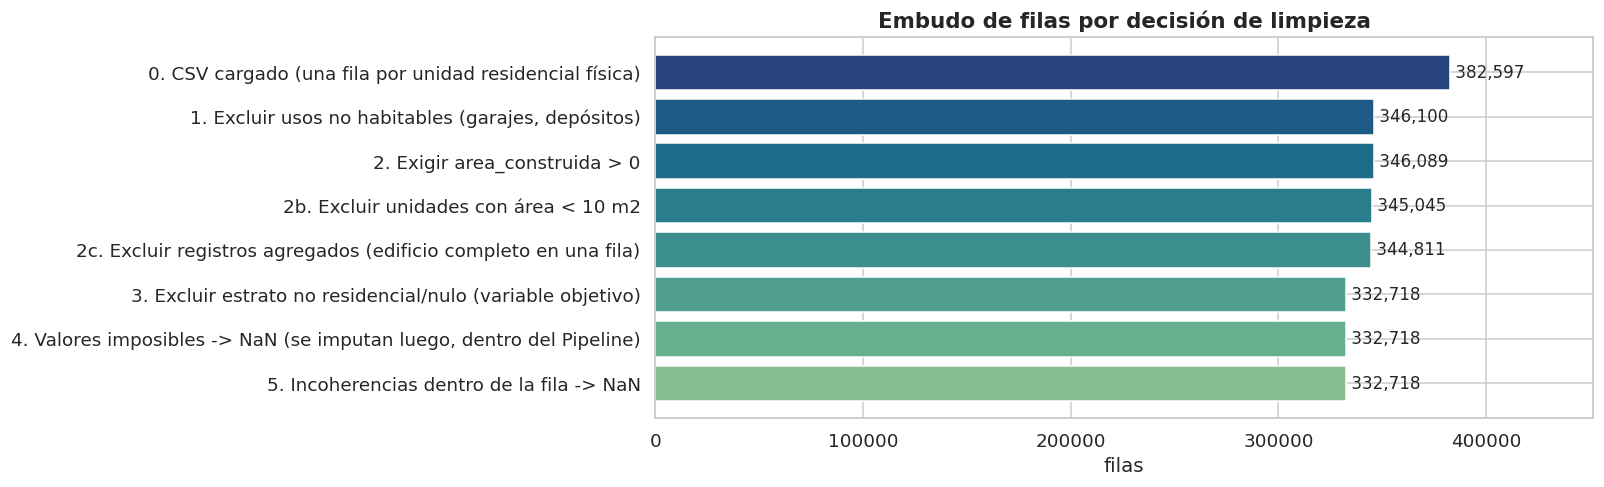

In [3]:
# Figura del embudo: barras horizontales con las filas que sobreviven a cada regla.
# Permite ver de un vistazo qué decisión de limpieza elimina más filas.
fig, ax = plt.subplots(figsize=(11, 4.5))
# Se invierte el orden ([::-1]) para que el paso 0 quede arriba y se lea de arriba abajo.
ax.barh(embudo["paso"][::-1], embudo["filas"][::-1], color=sns.color_palette("crest", len(embudo)))
# Etiqueta con el número de filas al final de cada barra.
for i, v in enumerate(embudo["filas"][::-1]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=11)
ax.set_xlabel("filas")
ax.set_title("Embudo de filas por decisión de limpieza")
# Margen del 18 % a la derecha para que las etiquetas no se corten.
ax.set_xlim(0, embudo["filas"].max() * 1.18)
G.guardar(fig, "01_embudo")  # se guarda en figuras/ para el informe
plt.show()

Vista de las primeras filas. Por la **consideración ética** de la sección 1.8
el número predial se muestra truncado (identifica un inmueble concreto).

In [4]:
# Vista de las primeras filas con el número predial enmascarado (consideración
# ética 1.8: el NPN completo identifica un inmueble concreto y permite reidentificar).
def enmascarar_npn(s):
    # Conserva solo los 12 primeros dígitos (depto, municipio, zona, sector...),
    # que ubican la zona pero no el predio individual.
    return s.astype("string").str[:12] + "…"

# Se omiten las columnas de bandera (flag_*) para que la vista sea legible.
vista = df.drop(columns=df.filter(like="flag_").columns).head(5).copy()
vista["numero_predial_nacional"] = enmascarar_npn(vista["numero_predial_nacional"])
vista["npn_edificio"] = enmascarar_npn(vista["npn_edificio"])
vista.T  # transpuesta: una fila por variable, más fácil de leer con muchas columnas

,0,1,2,3,4
id_fila,14,23,49,50,53
numero_predial_nacional,080010002000…,080010002000…,080010003000…,080010003000…,080010003000…
estrato,Bajo_Bajo_1,Bajo_Bajo_1,Bajo_Bajo_1,Bajo_Bajo_1,Bajo_Bajo_1
tipo_vivienda,tv_4,tv_4,tv_4,tv_4,tv_4
destinacion_economica,Habitacional,Habitacional,Habitacional,Habitacional,Habitacional
condicion_predio,Informal,Informal,NPH,NPH,NPH
area_catastral_terreno,0.000,0.000,"4,932.200","4,932.200","1,142.400"
area_construida,44.740,44.740,39.540,39.540,39.540
uso,Residencial_Vivienda_Hasta_3_Pisos,Residencial_Vivienda_Hasta_3_Pisos,Residencial_Vivienda_Hasta_3_Pisos,Residencial_Vivienda_Hasta_3_Pisos,Residencial_Vivienda_Hasta_3_Pisos
tipo_planta,Piso,Piso,Piso,Piso,Piso


## 1.4 Diccionario de variables

El rol de cada variable (objetivo, predictora, identificador, metadato) se
justifica en la auditoría de fuga (capítulo 9). Si el servidor responde, se
descargan también los alias y dominios oficiales de ArcGIS (por ejemplo, el
significado de los códigos de `tipo_vivienda`).

In [5]:
# Diccionario de variables: nombre, tipo, unidad, significado y ROL en el modelo.
# El rol (objetivo, predictora, identificador, metadato) es lo que luego se audita
# en el capítulo 9 para asegurar que ninguna columna con fuga entre al modelo.
dicc = pd.DataFrame([
    ("numero_predial_nacional", "texto (30 dígitos)", "—", "Número predial nacional (IGAC): depto, municipio, zona, sector, comuna, barrio, manzana, terreno, condición, edificio, piso, unidad", "identificador"),
    ("npn_edificio", "texto (22 dígitos)", "—", "Prefijo del NPN que identifica el edificio/lote (derivada)", "identificador / grupo"),
    ("estrato", "categórica ordinal (texto)", "—", "Estrato socioeconómico tal como llega de ArcGIS (Bajo_Bajo_1 … Alto_6, No_Aplica, Otro)", "origen del objetivo"),
    ("estrato_num", "categórica ordinal", "1–6", "Estrato numérico extraído del texto", "OBJETIVO"),
    ("area_construida", "numérica continua", "m²", "Área construida de la unidad", "predictora"),
    ("area_catastral_terreno", "numérica continua", "m²", "Área del terreno del predio (0 en unidades PH sin lote propio)", "predictora"),
    ("total_habitaciones", "numérica discreta", "conteo", "Número de habitaciones", "predictora"),
    ("total_banios", "numérica discreta", "conteo", "Número de baños", "predictora"),
    ("total_plantas", "numérica discreta", "conteo", "Número de plantas/pisos de la construcción", "predictora"),
    ("anio_construccion", "numérica discreta", "año", "Año de construcción", "origen de antigüedad"),
    ("antiguedad", "numérica discreta", "años", f"{C.ANIO_ACTUAL} − año de construcción (derivada)", "predictora"),
    ("planta_ubicacion", "numérica discreta", "piso", "Piso en que está la unidad", "predictora"),
    ("altura", "numérica continua", "m (verificar)", "Altura de la unidad de construcción", "predictora"),
    ("tipo_vivienda", "categórica nominal (código)", "—", "Código de dominio ArcGIS del tipo de vivienda", "predictora"),
    ("uso", "categórica nominal", "—", "Uso catastral de la unidad (casa, apartamento en PH, barraca…)", "predictora"),
    ("condicion_predio", "categórica nominal", "—", "Régimen: NPH (no propiedad horizontal), PH_Matriz, PH_Unidad_Predial, Informal…", "predictora"),
    ("destinacion_economica", "categórica nominal", "—", "Destinación económica del predio", "predictora"),
    ("tipo_planta", "categórica nominal", "—", "Tipo de planta (Piso, Sótano, Mezanine…)", "predictora"),
    ("centroide_lat / centroide_lon", "numérica continua", "grados (WGS84, EPSG:4326)", "Centroide del terreno del predio (o de su edificio matriz)", "espacial"),
    ("x_km / y_km", "numérica continua", "km", "Coordenadas proyectadas localmente, origen en el centro histórico (derivada)", "predictora espacial"),
    ("dist_centro_km", "numérica continua", "km", "Distancia al centro histórico (derivada)", "predictora espacial"),
    ("centroide_fuente", "categórica nominal", "—", "Cómo se obtuvo el centroide: directo / propagado_matriz / sin_dato (metadato del pipeline)", "metadato (excluida)"),
    ("flag_imposible_*", "booleana", "—", "Marca si el valor original era físicamente imposible y se convirtió en NaN", "auditoría"),
    ("flag_incoherente_*", "booleana", "—", "Marca si el valor era incoherente con el resto de la fila (baños o habitaciones) y se convirtió en NaN", "auditoría"),
], columns=["variable", "tipo", "unidad", "significado", "rol"])

# Intento opcional de enriquecer el diccionario con los alias y dominios oficiales
# del servicio ArcGIS (se descargan una vez y se guardan en datos/dominios_arcgis.json).
try:
    from src.dominios import descargar_dominios
    dominios = descargar_dominios()
    # Alias oficial de cada campo; queda vacío para las variables derivadas.
    dicc["alias ArcGIS"] = dicc["variable"].map(lambda v: (dominios.get(v) or {}).get("alias"))
    # Tabla código -> significado de tipo_vivienda (llega como código numérico).
    tv = (dominios.get("tipo_vivienda") or {}).get("dominio")
    if tv:
        print("Dominio oficial de tipo_vivienda:", tv)
except Exception as e:  # sin internet o bloqueado: el libro sigue
    print(f"(No se pudieron descargar los dominios de ArcGIS: {type(e).__name__}. "
          "El diccionario se muestra sin alias oficiales.)")
dicc

Dominio oficial de tipo_vivienda: {'1': 'Vivienda de Interés Social', '2': 'Vivienda de Interés Prioritario', '3': 'Vivienda que no es de interés social', '4': 'No Aplica'}


,variable,tipo,unidad,significado,rol,alias ArcGIS
0,numero_predial_nacional,texto (30 dígitos),—,"Número predial nacional (IGAC): depto, municip...",identificador,Número Predial Nacional
1,npn_edificio,texto (22 dígitos),—,Prefijo del NPN que identifica el edificio/lot...,identificador / grupo,NaN
2,estrato,categórica ordinal (texto),—,Estrato socioeconómico tal como llega de ArcGI...,origen del objetivo,Estrato
3,estrato_num,categórica ordinal,1–6,Estrato numérico extraído del texto,OBJETIVO,NaN
4,area_construida,numérica continua,m²,Área construida de la unidad,predictora,Área Construida
5,area_catastral_terreno,numérica continua,m²,Área del terreno del predio (0 en unidades PH ...,predictora,Área Catastral Terreno
6,total_habitaciones,numérica discreta,conteo,Número de habitaciones,predictora,Total Habitaciones
7,total_banios,numérica discreta,conteo,Número de baños,predictora,Total Baños
8,total_plantas,numérica discreta,conteo,Número de plantas/pisos de la construcción,predictora,Total Pisos
9,anio_construccion,numérica discreta,año,Año de construcción,origen de antigüedad,Año Construcción


## 1.5 Estructura de los datos

- **Unidad de observación:** la *unidad residencial física* (una fila de la
  capa 505 "Características" = una casa o un apartamento). Cada fila se une a
  su unidad de construcción, a su predio y al centroide del terreno. Las
  filas que no describen una vivienda individual (parqueaderos o depósitos
  de menos de 10 m², edificios completos en una sola fila) se excluyen en el
  embudo (pasos 2b y 2c, sección 1.7.3).
- **Nivel de agregación:** unidad de vivienda (no manzana ni barrio). Varias
  unidades pueden pertenecer al mismo predio y al mismo edificio.
- **Tipo de datos:** **transversal con componente espacial** (una foto del
  catastro en la fecha de descarga). `anio_construccion` es un atributo, no una
  marca temporal de la observación, así que no aplica la sección 2.6
  (componente temporal) ni la 2.8 (espacio-temporal).
- **Jerarquía:** unidad ⊂ predio (NPN de 30 dígitos) ⊂ edificio/lote (prefijo
  de 22 dígitos) ⊂ manzana ⊂ barrio. Esta jerarquía es la razón para partir
  por grupos/bloques y no por filas.

## 1.6 Tamaño de la muestra, relación n/p y entidades independientes

**¿Qué es la relación n/p?** Es el número de filas (**n**) dividido entre el número de columnas que entran al modelo (**p**): cuántos datos hay por cada cosa que el modelo debe aprender. Si hay pocas filas por columna, el modelo memoriza los datos en lugar de aprender patrones generales (**sobreajuste**); por eso se busca que n sea mucho mayor que p. Una referencia usual para regresión logística es tener al menos 10 casos de la clase menos frecuente por columna (Peduzzi et al., 1996).

*¿Qué es one-hot?* Los modelos solo trabajan con números, así que cada categoría se convierte en una columna de 0 y 1. Por ejemplo, `condicion_predio` se vuelve una columna "¿es NPH?", otra "¿es PH_Unidad_Predial?", otra "¿es Informal?", etc. Por eso p no son las 16 variables candidatas, sino las ≈ 35 columnas que quedan tras one-hot.

*En este catastro:* n/p ≈ 332 718 ÷ 35 ≈ **9 500 filas por columna**, y el estrato 6 tiene unos 377 casos por columna, muy por encima de 10. No faltan datos para el número de variables.

In [6]:
# Tamaño de muestra y relación n/p: verifica el mínimo de 20 000 observaciones de
# las instrucciones del proyecto y que haya suficientes filas por parámetro. También cuenta entidades
# (predios, edificios), porque las filas de un mismo edificio no son independientes.
n = len(df)
p_num = len(C.NUMERICAS) + len(C.ESPACIALES)   # numéricas + coordenadas/distancia
p_cat = len(C.CATEGORICAS)
# Tras one-hot cada nivel de una categórica se vuelve una columna: se suman niveles.
n_niveles = sum(df[c].nunique() for c in C.CATEGORICAS if c in df)
p_efectivo = p_num + n_niveles
predios = df["numero_predial_nacional"].nunique()   # NPN de 30 dígitos
edificios = df["npn_edificio"].nunique()            # prefijo de 22 dígitos (edificio/lote)
tam = pd.DataFrame({
    "valor": [n, p_num + p_cat, p_efectivo, n / p_efectivo, predios, edificios,
              int(df["tiene_coordenadas"].sum())],
}, index=["filas (unidades de vivienda)", "variables predictoras candidatas",
          "columnas tras one-hot (aprox.)", "n / p (con one-hot)",
          "predios únicos (NPN)", "edificios/lotes únicos (NPN 22 díg.)",
          "filas con coordenadas"])
tam

,valor
filas (unidades de vivienda),"332,718.000"
variables predictoras candidatas,16.000
columnas tras one-hot (aprox.),35.000
n / p (con one-hot),"9,506.229"
predios únicos (NPN),"320,792.000"
edificios/lotes únicos (NPN 22 díg.),"168,044.000"
filas con coordenadas,"278,824.000"


In [7]:
# Casos por clase del objetivo (estrato 1-6), en conteo y porcentaje, para dimensionar
# el desbalance antes de decidir la partición estratificada y las métricas.
casos = (df[C.OBJETIVO].value_counts().sort_index().rename("casos").to_frame()
         .assign(**{"%": lambda t: 100 * t["casos"] / t["casos"].sum()}))
casos.index = [C.NOMBRES_CLASES[i] for i in casos.index]  # etiquetas legibles ("1 Bajo-bajo"...)
casos

,casos,%
1 Bajo-bajo,108985,32.756
2 Bajo,72493,21.788
3 Medio-bajo,72000,21.640
4 Medio,49190,14.784
5 Medio-alto,16843,5.062
6 Alto,13207,3.969


**Tamaño efectivo (descriptivo).** Las unidades de un mismo predio matriz
comparten estrato casi siempre, así que no son observaciones independientes.
Se estima la correlación intraclase (ICC(1), ANOVA de una vía con el predio matriz
como grupo, tratando el estrato como numérico) y el **efecto de diseño de
Kish**: $\text{deff} = 1 + (\tilde m - 1)\,\text{ICC}$, con
$\tilde m = \sum_j m_j^2 / N$ (tamaño medio de grupo ponderado, adecuado
cuando los grupos tienen tamaños muy desiguales) y
$n_\text{ef} = n/\text{deff}$. Es una descripción del dataset completo: no
alimenta ninguna decisión de modelado.

**Qué es el grupo.** Se usa el **predio matriz**: los 22 primeros dígitos del número predial (terreno y condición de propiedad). Puede ser una casa, un edificio o un conjunto residencial completo: el mayor tiene 1 860 apartamentos en 93 torres. Hay una excepción: cuando la condición de propiedad es 5 (*mejoras en terreno ajeno*), el catastro registra en un mismo lote matriz muchas viviendas informales independientes, así que cada mejora cuenta como su propio grupo. Sin esta corrección, el «edificio» más grande sería un lote del suroccidente de la ciudad con 3 045 viviendas informales, y el tamaño efectivo quedaría subestimado (≈ 1 870 en vez de ≈ 2 300).

In [8]:
# ICC(1) y efecto de diseño de Kish: miden cuánto se parecen en estrato las unidades
# de un mismo predio matriz y cuántas observaciones "independientes" equivalen a las filas.
# Es solo descriptivo (dataset completo); no alimenta ninguna decisión aprendida.
# Grupo = predio matriz (22 primeros dígitos del NPN). Las mejoras en terreno ajeno
# (dígito 22 = "5") son viviendas informales independientes: cada una es su propio grupo.
npn_txt = df["numero_predial_nacional"]
grupo = npn_txt.str[:22].where(npn_txt.str[21] != "5", npn_txt)
g = df.groupby(grupo)[C.OBJETIVO]            # el predio matriz es el grupo del ANOVA
m = g.size()                                 # m_j: unidades por grupo
k, N = len(m), m.sum()                       # k grupos, N observaciones
media_total = df[C.OBJETIVO].mean()
# Sumas de cuadrados entre grupos (SSB) y dentro de grupos (SSW) del ANOVA de una vía.
ssb = (m * (g.mean() - media_total) ** 2).sum()
ssw = ((df[C.OBJETIVO] - g.transform("mean")) ** 2).sum()
msb, msw = ssb / (k - 1), ssw / (N - k)      # cuadrados medios con sus grados de libertad
# m0: tamaño de grupo "ajustado" para grupos desiguales (fórmula clásica del ICC(1)).
m0 = (N - (m ** 2).sum() / N) / (k - 1)
icc = (msb - msw) / (msb + (m0 - 1) * msw)
# Tamaño medio ponderado Σm²/N: da más peso a las torres grandes, que son las que
# más inflan la varianza cuando los grupos tienen tamaños muy desiguales.
m_pond = (m ** 2).sum() / N
deff = 1 + (m_pond - 1) * icc                # efecto de diseño de Kish
print(f"Unidades por predio matriz: media {m.mean():.2f}, mediana {m.median():.0f}, máximo {m.max()}, "
      f"media ponderada Σm²/N {m_pond:.2f}")
print(f"ICC(1) del estrato dentro del predio matriz: {icc:.3f}")
# Tamaño efectivo n_ef = N / deff: filas equivalentes si fueran independientes.
print(f"Efecto de diseño: {deff:.2f}  ->  tamaño efectivo aprox. {N / deff:,.0f} "
      f"(frente a {N:,} filas)")

Unidades por predio matriz: media 1.82, mediana 1, máximo 1860, media ponderada Σm²/N 145.42
ICC(1) del estrato dentro del predio matriz: 0.992
Efecto de diseño: 144.27  ->  tamaño efectivo aprox. 2,306 (frente a 332,718 filas)


```{admonition} Interpretación
:class: note
- **Tamaño bruto.** Tras el embudo quedan **332 718 unidades de vivienda**
  (87.0 % de las 382 597 filas descargadas), en **320 792 predios** y
  **168 044 predios matriz** (edificios, conjuntos o lotes); 278 824 filas (83.8 %) tienen coordenadas. La
  relación n/p es de ~9 500 filas por columna tras one-hot (35 columnas): el
  problema no es de pocos datos respecto al número de variables, y el mínimo
  de 20 000 observaciones de las instrucciones del proyecto se cumple con holgura.
- **Clases.** Estrato 1: 32.8 %, 2: 21.8 %, 3: 21.6 %, 4: 14.8 %, 5: 5.1 %,
  6: 4.0 %. Las dos clases altas suman menos del 10 %, pero aún tienen más de
  13 000 casos cada una (16 843 y 13 207).

**Dependencia dentro del predio matriz.** El ICC(1) es **0.992**: dentro de un edificio o conjunto el estrato prácticamente no varía. Esto quiere decir que cien apartamentos de una misma torre aportan casi la misma información sobre el estrato que uno solo. Es como fotocopiar una hoja 1 000 veces: hay 1 000 hojas, pero una sola página de información. Por eso las filas no son datos independientes, y la muestra vale menos de lo que sugiere su número de filas.

*Cómo se mide esa pérdida.* Se usa el efecto de diseño (deff), que dice cuántas veces es menos precisa nuestra muestra que una de observaciones independientes. Un deff de 1 significa que no hay repetición; un deff de 100 significa que haría falta 100 veces más datos para tener la misma precisión. Se aproxima así:

$$
\text{deff} \approx 1 + (m - 1) \times \text{ICC}
$$

donde ICC mide qué tanto se parecen entre sí las viviendas de un mismo predio matriz (0 = nada, 1 = son idénticas) y $m$ es el tamaño medio del grupo **visto desde una vivienda**.

*Por qué $m$ no es el promedio por edificio.* Hay dos formas de calcular el "tamaño promedio" de un edificio:

- Preguntarle a cada **edificio** cuántas viviendas tiene. La mediana es 1 unidad, porque la mayoría son casas.
- Preguntarle a cada **vivienda** cuántas viviendas hay en su edificio, y promediar las respuestas.

Un ejemplo: en un barrio con 99 casas y una torre de 901 apartamentos hay 100 edificios y 1 000 viviendas. Por edificio el promedio es 10. Pero 901 de las 1 000 viviendas viven en la torre, así que, preguntando a las viviendas, el promedio es (99 × 1 + 901 × 901) ÷ 1 000 ≈ 812. Es un promedio ponderado por tamaño: los edificios grandes pesan más porque contienen más filas, y las filas son lo que usamos para modelar. Esa segunda forma es la que importa para medir la repetición.

*En este catastro.* La mediana es 1 unidad por grupo, pero hay conjuntos de hasta **1 860 unidades** (93 torres en un mismo predio matriz). Visto desde una vivienda, el grupo típico tiene unas 145 unidades ($m = 145$). Con los valores sin redondear, el efecto de diseño es **144.3**, y el tamaño efectivo "tipo muestra independiente" es n ÷ deff = 332 718 ÷ 144.3 ≈ **2 300**.

**Cómo leer ese 2 300.** No es un conteo de viviendas, de predios, de edificios ni de combinaciones de características: es una medida de precisión. Significa que las estimaciones sobre el estrato tienen la precisión de unas 2 300 observaciones independientes, no de 332 718. Tampoco significa que sobren o falten filas: hay 168 044 predios matriz distintos, muy por encima del mínimo de 20 000. Lo que indica es que la precisión de cualquier estimación sobre el estrato está gobernada por los edificios, los conjuntos y las zonas, no por las filas. Dos consecuencias prácticas: (1) la partición debe mantener juntas las unidades de un mismo edificio y de una misma zona (cap. 2), para que una torre nunca quede repartida entre entrenamiento y prueba; y (2) los intervalos de confianza deben remuestrear bloques, no filas (cap. 10). El cálculo usa el dataset completo solo como descripción; no alimenta ninguna decisión aprendida.
```

## 1.7 Calidad de datos

### 1.7.1 Valores faltantes (panorama)

Aquí solo se cuentan. El **patrón** (matriz de nulos) y el **mecanismo**
(MCAR/MAR/MNAR) se analizan en el capítulo 3 usando solo entrenamiento.
Dos columnas separan los nulos que crearon las reglas de limpieza: "de
ellos, por valor imposible" (banderas `flag_imposible_*`, paso 4) y "de
ellos, por incoherencia" (banderas `flag_incoherente_*`, paso 5). Los nulos
de `planta_ubicacion` (0.105 %), `anio_construccion` (0.039 %) y
`total_plantas` (0.001 %) son todos valores imposibles; los de
`total_habitaciones` (0.107 %) y `total_banios` (0.012 %) son todos
incoherencias (355 y 41 filas, tabla de la sección 1.7.3). `antiguedad`
aparece con 0 en ambas columnas porque no tiene bandera propia: sus nulos
son los del año de construcción, del que se deriva. El faltante dominante
es la coordenada (16.2 % de las filas).

In [9]:
# Panorama de faltantes: solo se CUENTAN aquí (sobre todo el dataset, sin aprender
# nada). El patrón y el mecanismo MCAR/MAR/MNAR se estudian en el cap. 3 solo con train.
cols_revisar = C.NUMERICAS + C.CATEGORICAS + ["anio_construccion", "centroide_lat", "numero_predial_nacional"]
# % de nulos por columna tras las reglas de limpieza, ordenado de mayor a menor.
nulos = (df[cols_revisar].isna().mean().mul(100).rename("% nulos (tras reglas)")
         .to_frame().sort_values("% nulos (tras reglas)", ascending=False))
# Parte de esos nulos que generaron las reglas de limpieza: valores imposibles
# (bandera flag_imposible_*, paso 4) e incoherencias dentro de la fila (bandera
# flag_incoherente_*, paso 5); 0 si la variable no tiene regla.
nulos["de ellos, por valor imposible"] = [
    100 * df[f"flag_imposible_{c}"].mean() if f"flag_imposible_{c}" in df else 0.0 for c in nulos.index]
nulos["de ellos, por incoherencia"] = [
    100 * df[f"flag_incoherente_{c}"].mean() if f"flag_incoherente_{c}" in df else 0.0 for c in nulos.index]
nulos

,% nulos (tras reglas),"de ellos, por valor imposible","de ellos, por incoherencia"
centroide_lat,16.198,0.000,0.000
total_habitaciones,0.107,0.000,0.107
planta_ubicacion,0.105,0.105,0.000
antiguedad,0.039,0.000,0.000
anio_construccion,0.039,0.039,0.000
total_banios,0.012,0.000,0.012
total_plantas,0.001,0.001,0.000
area_catastral_terreno,0.001,0.000,0.000
altura,0.000,0.000,0.000
area_construida,0.000,0.000,0.000


### 1.7.2 Duplicados exactos y casi-duplicados

Tres niveles, de más a menos estricto:
1. **Duplicado exacto** en todas las columnas originales (incluido el NPN).
2. **Mismo NPN** (varias unidades físicas registradas bajo un mismo número
   predial).
3. **Casi-duplicado:** mismas características físicas y mismo edificio, pero
   distinta fila (apartamentos idénticos en serie).

In [10]:
# Duplicados en tres niveles de exigencia. Sirve para distinguir errores de carga
# (duplicado exacto) de unidades reales repetidas que hay que agrupar al partir.
# Columnas originales del CSV: se excluye 'id_fila' porque es única por construcción.
cols_orig = [c for c in crudo.columns if c != "id_fila"]
cols_fisicas = ["area_construida", "total_habitaciones", "total_banios", "total_plantas",
                "anio_construccion", "uso", "tipo_vivienda"]
dup = pd.DataFrame({
    "filas": [
        # Nivel 1: filas idénticas en todas las columnas originales (se cuenta la copia).
        int(df.duplicated(subset=[c for c in cols_orig if c in df]).sum()),
        # Nivel 2: keep=False marca TODAS las filas que comparten NPN, no solo la segunda.
        int(df["numero_predial_nacional"].duplicated(keep=False).sum()),
        # Nivel 3: mismo edificio y mismas características físicas (apartamentos en serie).
        int(df.duplicated(subset=["npn_edificio"] + cols_fisicas, keep=False).sum()),
    ]}, index=["1. duplicado exacto (todas las columnas)",
               "2. NPN repetido (varias unidades por predio)",
               "3. casi-duplicado (mismo edificio + mismas características)"])
dup["% del total"] = 100 * dup["filas"] / len(df)
dup

,filas,% del total
1. duplicado exacto (todas las columnas),0,0.000
2. NPN repetido (varias unidades por predio),22707,6.825
3. casi-duplicado (mismo edificio + mismas características),127601,38.351


```{admonition} Interpretación y decisión
:class: note
- El bug de uniones muchos-a-muchos que producía ~29 % de filas repetidas ya
  se corrigió en `01_descarga_predios.py` (bitácora 3.1): con los datos
  reales el nivel 1 es **0 filas**.
- Nivel 2: **22 707 filas (6.8 %)** comparten NPN con otra fila (varias
  construcciones registradas bajo un mismo predio). Nivel 3: **127 601 filas
  (38.4 %)** son casi-duplicados: apartamentos en serie con idénticas
  características dentro del mismo edificio.
- Los niveles 2 y 3 **no son errores**: son unidades reales distintas
  (apartamentos idénticos de un mismo proyecto, dos construcciones en un mismo
  lote). Eliminarlas borraría viviendas reales. **Decisión:** se conservan,
  pero se tratan como una misma *entidad* al partir los datos (bloques
  espaciales, capítulo 2), para que un apartamento no quede en
  entrenamiento y su "gemelo" en prueba.
```

### 1.7.3 Valores imposibles o inconsistentes

Rangos de dominio (no aprendidos de los datos). Los valores fuera de rango se
convierten en `NaN` y se marcan con una bandera `flag_imposible_*`; **no se
elimina la fila** (paso 4 del embudo). Las dos últimas filas de la tabla son
las reglas de coherencia del paso 5: el valor sospechoso pasa a `NaN` con
bandera `flag_incoherente_*` y la fila también se conserva.

In [11]:
# Tabla generada por L.limpiar: por variable, el rango plausible de dominio
# (definido en config, no aprendido de los datos) y cuántos valores cayeron fuera.
tabla_imposibles

,variable,rango plausible,n imposibles,%
0,total_habitaciones,"[0, 30]",0,0.000
1,total_banios,"[0, 20]",0,0.000
2,total_plantas,"[0, 40]",4,0.001
3,planta_ubicacion,"[1, 60]",351,0.105
4,area_construida,"[1, 20000]",0,0.000
5,area_catastral_terreno,"[0, 50000]",0,0.000
6,anio_construccion,"[1900, 2026]",129,0.039
7,total_banios (coherencia),<= habitaciones + 3,41,0.012
8,total_habitaciones (coherencia),área / habitación >= 6 m2,355,0.107


#### Alcance: ¿cada fila es una vivienda? (reglas 2b, 2c y 5 del embudo)

Un rango por variable no basta. El diagnóstico de rangos
(`diagnostico_rangos.py`, bitácora A.10; reporte en `diagnostico_rangos_reporte.txt`), hecho **en el diagnóstico previo,
sobre el conjunto de entrenamiento** (para no mirar el conjunto de prueba al
definir las reglas), mostró que los valores
extremos de habitaciones, baños y área no eran errores de digitación
aislados, sino **filas que no describen una vivienda**. Las cifras de esta
subsección que dicen "en el diagnóstico previo" provienen de ese reporte;
el efecto de las reglas sobre el dataset completo es el del embudo (1.3) y
el de la celda siguiente.

- **Registros agregados.** Filas `NPH` que describen un edificio completo:
  en el diagnóstico previo, la más extrema tenía 684 habitaciones, 456
  baños, 19 pisos y 52 168 m². Se excluyen del alcance (paso 2c: más de 20
  habitaciones, más de 15 baños o más de 2 000 m²), igual que los garajes y
  depósitos.
- **Unidades diminutas.** En el diagnóstico previo, sobre el conjunto de
  entrenamiento, había 215 filas de menos de 5 m² y 656 de menos de 10 m²,
  en todos los estratos y a menudo con 0 baños o con el piso "99" (código).
  Son, sobre todo, parqueaderos o depósitos registrados con uso
  residencial. Se excluyen con un área mínima de 10 m² (paso 2b). No se usó
  un umbral mayor (15 o 20 m²) para no sacar viviendas mínimas reales de uno
  o dos cuartos, que son las de los hogares más pobres: un sesgo así
  afectaría justamente a los estratos 1 y 2.
- **Piso de ubicación.** Los valores 97, 98 y 99 son códigos (299 filas en
  el diagnóstico previo, sobre el conjunto de entrenamiento), pero hay pisos
  **reales** hasta el 41: 41 apartamentos en PH de estratos 5 y 6 entre los
  pisos 30 y 41. Por eso el techo de `planta_ubicacion` se fija en 60 (y no
  en 40, como el de `total_plantas`): deja pasar esas torres y sigue
  atrapando los códigos.
- **Incoherencias dentro de la fila.** Valores que por separado están en
  rango pero son imposibles dado el resto de la fila: por ejemplo, en el
  diagnóstico previo apareció un apartamento de 2 habitaciones y 82 m² con
  82 baños. Las reglas son: más baños que habitaciones + 3, o menos de 6 m²
  por habitación. Se anula el valor sospechoso (NaN + bandera
  `flag_incoherente_*`) y la fila se conserva (paso 5).

¿Por qué no usar la regla de Tukey para limpiar? Las notas de clase
(9.10.4.1.2) la proponen para **identificar** outliers, y así se usa en el
capítulo 3. Pero en variables de cola larga marca miles de viviendas reales:
en el diagnóstico previo, sobre el conjunto de entrenamiento, señalaba
10 580 filas en habitaciones y 13 009 en área. Por eso aquí se separan los
dos conceptos. **Imposible** (error, código o fila que no es
vivienda) se trata con reglas de dominio fijas, fila a fila y antes del
split. **Extremo pero posible** (una casa grande de estrato 6) se conserva y
lo controla la winsorización p0.1/p99.9 aprendida en train dentro del
Pipeline. Todos los umbrales viven en `src/config.py`.

Dos hallazgos del diagnóstico **no** se convirtieron en reglas y quedan como
limitaciones. (i) En el diagnóstico previo, sobre el conjunto de
entrenamiento, había 2 014 filas con 0 habitaciones y 7 145 con 0 baños:
pueden ser apartaestudios o viviendas con baño compartido, o un "dato no
registrado"; sin el diccionario del catastro no se puede decidir, así que
se conservan. (ii) El año de construcción está **amontonado** en ciertos
valores (en ese mismo diagnóstico, 1986 aparecía en 27 280 filas, el 12 %;
también 1932, 1940 y 1942), lo que sugiere años por defecto o aproximados del
catastro. La antigüedad debe leerse con esa cautela.

In [12]:
# Quiénes salen por las reglas de alcance 2b (área mínima) y 2c (registro
# agregado): se reproducen sobre el crudo tras los pasos 1 y 2 para describirlos por
# condición del predio, uso y estrato. Es una tabla descriptiva: los umbrales
# están fijados en config.py y no se ajustan aquí.
base = crudo.copy()
for col in ["uso", "condicion_predio", "estrato"]:
    base[col] = L._normalizar_texto(base[col])
base = base[~base["uso"].isin(C.USOS_NO_HABITABLES)]
area_b = pd.to_numeric(base["area_construida"], errors="coerce")
base = base[area_b > 0].copy()
base["estrato_num"] = L.extraer_estrato_numerico(base["estrato"])
for col in C.UMBRALES_REGISTRO_AGREGADO:
    base[col] = pd.to_numeric(base[col], errors="coerce")
regla_2b = base["area_construida"] < C.AREA_MIN_VIVIENDA
regla_2c = ~regla_2b & pd.concat([base[c] > u for c, u in C.UMBRALES_REGISTRO_AGREGADO.items()], axis=1).any(axis=1)
for nombre, m in [(f"2b: área < {C.AREA_MIN_VIVIENDA} m²", regla_2b), ("2c: registro agregado", regla_2c)]:
    sub = base[m]
    print(f"\n{nombre}: {int(m.sum()):,} filas")
    print("  condición del predio:", sub["condicion_predio"].value_counts().head(5).to_dict())
    print("  uso:", sub["uso"].value_counts().head(4).to_dict())
    print("  estrato (1-6; NaN = sin estrato residencial):",
          {(int(k) if pd.notna(k) else "NaN"): int(v)
           for k, v in sub["estrato_num"].value_counts(dropna=False).sort_index().items()})
    print("  área construida: mediana", round(sub["area_construida"].median(), 1),
          "| habitaciones: mediana", sub["total_habitaciones"].median())


2b: área < 10 m²: 1,044 filas
  condición del predio: {'PH_Unidad_Predial': 400, 'NPH': 354, 'Informal': 278}
  uso: {'Residencial_Vivienda_Hasta_3_Pisos': 643, 'Residencial_Vivienda_Hasta_3_Pisos_En_PH': 291, 'Residencial_Apartamentos_4_y_mas_pisos_en_PH': 108, 'Residencial_Vivienda_Recreacional_En_PH': 2}
  estrato (1-6; NaN = sin estrato residencial): {1: 294, 2: 253, 3: 270, 4: 138, 5: 36, 6: 6, 'NaN': 47}
  área construida: mediana 6.0 | habitaciones: mediana 1.0

2c: registro agregado: 234 filas
  condición del predio: {'NPH': 146, 'PH_Unidad_Predial': 28, 'Informal': 12, 'PH_Matriz': 6}
  uso: {'Residencial_Apartamentos_4_y_mas_pisos': 112, 'Residencial_Vivienda_Hasta_3_Pisos': 94, 'Residencial_Vivienda_Hasta_3_Pisos_En_PH': 17, 'Residencial_Apartamentos_4_y_mas_pisos_en_PH': 11}
  estrato (1-6; NaN = sin estrato residencial): {1: 18, 2: 18, 3: 45, 4: 37, 5: 22, 6: 16, 'NaN': 78}
  área construida: mediana 1161.0 | habitaciones: mediana 24.0


In [13]:
# Años de construcción fuera de rango en el CSV CRUDO (antes del embudo), con su
# frecuencia. Si un valor imposible se repite mucho, es un código centinela, no ruido.
anio_crudo = pd.to_numeric(crudo["anio_construccion"], errors="coerce")
top_raros = anio_crudo[(anio_crudo < C.ANIO_MIN_PLAUSIBLE) | (anio_crudo > C.ANIO_MAX_PLAUSIBLE)]
print("Años fuera de rango más frecuentes (crudo):")
print(top_raros.value_counts().head(10).to_string())

Años fuera de rango más frecuentes (crudo):
anio_construccion
2500    809
1512    200
20        1


```{admonition} Hallazgo: códigos centinela en el año y en el piso
:class: important
En el CSV crudo, el año `2500` aparece **809 veces**, `1512` **200 veces** y
`20` una vez. Un año imposible repetido de forma idéntica no es un error de
digitación aleatorio: es un **código centinela** del sistema de origen para
"año desconocido". No hay ningún dato real entre el año 20 y 1899; el primer
año real es 1900, de ahí el límite inferior (bitácora 3.2). La mayoría de
esas filas pertenecen a garajes, depósitos o predios sin estrato y salen en
los pasos previos del embudo; dentro del dataset de trabajo quedan **129
años imposibles (0.04 %)**, que se tratan como **faltantes**, no como años.

`planta_ubicacion` muestra el mismo patrón: los pisos 97, 98 y 99 no
existen en Barranquilla y se tratan como código. El rango plausible es
[1, 60]: el techo queda por encima de los pisos reales más altos y por
debajo de los códigos. La regla anula **351 valores (0.11 %)** del dataset
de trabajo; en entrenamiento, tras la regla, el p99.9 del piso es 20 y el
máximo 41 (cap. 3), es decir, las torres altas reales se conservan.

Los extremos de habitaciones, baños y área construida **ya no se anulan
valor a valor**: las filas con más de 20 habitaciones, más de 15 baños o
más de 2 000 m² se excluyen como **registros agregados** en el paso 2c,
porque describen un edificio completo, no una vivienda. Son **234 filas**,
sobre todo `NPH` (146) y con uso de apartamentos de 4 y más pisos (112), con
una mediana de 1 161 m² y 24 habitaciones; 78 de ellas tampoco tenían
estrato residencial. La regla 2b excluye **1 044 filas** de menos de 10 m²
(mediana de 6 m²), repartidas en todos los regímenes (400
`PH_Unidad_Predial`, 354 `NPH`, 278 `Informal`) y en todos los estratos
(294 de estrato 1, 253 de 2, 270 de 3, 138 de 4, 36 de 5 y 6 de 6): no es
una regla que afecte solo a la vivienda informal.

Como consecuencia, en la tabla de rangos habitaciones, baños y área
construida tienen **0 valores imposibles**, y `total_plantas` solo 4. En
total, **484 filas (0.15 %)** tienen al menos un valor imposible (paso 4),
casi tres de cada cuatro por el piso, y **396 filas (0.12 %)** tienen una
incoherencia (paso 5: 355 con menos de 6 m² por habitación y 41 con más
baños que habitaciones + 3). Siguiendo el precedente de De Cock (2011) de
documentar y tratar de forma simple los casos marginales, esos valores se
convierten en NaN y se imputan dentro del Pipeline; ninguna fila se elimina
en los pasos 4 y 5.
```

**Categorías mal escritas / inconsistentes.** `src/limpieza.py` normaliza
espacios y guiones bajos (`"No Aplica"` → `"No_Aplica"`). Con los datos
reales, solo `estrato` tenía variantes (9 categorías crudas → 8
normalizadas). `destinacion_economica` tiene 18 categorías en el crudo, pero
en el dataset de trabajo es casi constante ("Habitacional", cap. 5). Conteo de
variantes en el crudo:

In [14]:
# Categorías mal escritas: compara cuántas categorías hay antes y después de la
# normalización de texto de limpieza.py. Si el número baja, había variantes
# ("No Aplica" vs "No_Aplica") que se habrían tratado como niveles distintos.
for col in ["estrato", "condicion_predio", "tipo_planta", "destinacion_economica"]:
    crudas = crudo[col].astype("string").str.strip()               # sin espacios extremos
    normalizadas = crudas.str.replace(r"\s+", "_", regex=True)     # espacios internos -> "_"
    print(f"{col:<24} categorías crudas: {crudas.nunique():>3}  ->  normalizadas: {normalizadas.nunique():>3}")

estrato                  categorías crudas:   9  ->  normalizadas:   8
condicion_predio         categorías crudas:   5  ->  normalizadas:   5


tipo_planta              categorías crudas:   3  ->  normalizadas:   3


destinacion_economica    categorías crudas:  18  ->  normalizadas:  18


**Unidades.** Las áreas están en m² (servicio catastral); la `altura` debe
verificarse (metros o número de pisos) mirando su distribución en el
capítulo 5.

### 1.7.4 Sesgos de muestreo y representatividad

El catastro no es una muestra sino (casi) un censo de los predios formales,
pero tiene dos sesgos conocidos que se cuantifican en el capítulo 3:

1. **Predios informales sin coordenadas** (16.2 % de las filas de trabajo): no
   tienen terreno propio ni edificio matriz, así que no se pueden ubicar ni
   asignar a un bloque espacial. Quedan fuera del modelo, y como son
   mayoritariamente de estratos bajos, el modelo representa sobre todo la
   ciudad **formal**.
2. **Predios sin estrato residencial** (`No_Aplica`/`Otro`/nulo: 12 093
   filas en el paso 3 del embudo, 3.2 % del crudo): excluidos por ser la
   variable objetivo.

Además, la información catastral puede estar desactualizada respecto a la
realidad física (reformas no declaradas), lo que añade ruido en las
predictoras.

## 1.8 Consideraciones éticas

- **Datos personales:** el dataset no trae nombres ni cédulas de
  propietarios. Sin embargo, el **número predial** y las **coordenadas**
  identifican un inmueble concreto, y con ellos se puede consultar
  información registral: hay **riesgo de reidentificación** indirecta.
- **Mitigación aplicada en el libro:** el NPN se muestra truncado; los mapas
  se presentan agregados (hexbin, grilla) o con puntos pequeños sin
  etiquetas; no se publica la tabla fila a fila con coordenadas.
- **Uso del estrato:** es una etiqueta socioeconómica. Un modelo que la
  predice podría usarse para discriminar (p. ej. en crédito o seguros). El
  propósito aquí es analítico y de apoyo a la política pública; se declara
  explícitamente que el modelo **no** debe usarse para decisiones sobre
  personas.
- **Sesgo de cobertura:** los asentamientos informales quedan
  sub-representados; cualquier conclusión aplica a la ciudad formal.

## 1.9 Resumen del capítulo

```{admonition} Resumen
:class: note
- De 382 597 filas descargadas quedan **332 718 unidades de vivienda**
  (−36 497 garajes/depósitos, −11 sin área, −1 044 unidades de menos de
  10 m², −234 registros agregados, −12 093 sin estrato residencial), muy por
  encima del mínimo de 20 000. La precisión, sin embargo, está gobernada
  por los edificios y conjuntos (ICC = 0.992; tamaño efectivo ≈ 2 300).
- No hay duplicados exactos; las unidades repetidas (6.8 % por NPN, 38.4 %
  casi-duplicados) son viviendas reales y se manejan agrupando por
  edificio/bloque al partir.
- Las filas que no son una vivienda (parqueaderos o depósitos de menos de
  10 m², edificios completos en una fila) se excluyen del alcance; los
  valores imposibles que quedan son muy pocos (≤ 0.04 % por variable, salvo
  el piso, 0.11 %, por códigos como el 99), incluyen códigos centinela (año
  2500/1512) y, junto con las incoherencias dentro de la fila (396 filas,
  0.12 %), se tratan como faltantes a imputar dentro del Pipeline.
- Riesgos éticos: reidentificación por NPN + coordenadas y uso
  discriminatorio del estrato; se mitigan con agregación y declarando el
  alcance.
```